#### Setup

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#### Model Parameters

In [4]:
params = {
    "k10": 9.9594e6,      # dm3/(mol*min)
    "k20": 8.66124e9,     # dm3/(mol*min)
    "k30": 9.9594e6,      # dm3/(mol*min)
    "E1": 6666.7,          # K
    "E2": 8333.3,          # K
    "E3": 11111.0,         # K
    "cA0": 10.0,            # mol/dm3
    "cB0": 10.0,            # mol/dm3
    "V": 2105.0,             # dm3
    "QA": 112.35,           # dm3/min
}


QB_bounds = (180.0, 360.0)                     # dm3/min
Tr_bounds = (75 + 273.15, 100 + 273.15)         # K (source: 75-100 degC)

#### Reaction Rate Help Function

In [6]:
def reaction_rates(c, Tr, p):
    """
    Computes the three reaction rates r1, r2, r3.

    Inputs:
        c  : array of 6 floats [cA, cB, cC, cP, cE, cG]
             current concentrations in mol/dm3
        Tr : float
             reactor temperature in K
        p  : dict
             plant parameters (params)

    Output:
        r1, r2, r3 : tuple of 3 floats
                     reaction rates in mol/(dm3*min)
    """
    cA, cB, cC, cP, cE, cG = c

    k1 = p["k10"] * np.exp(-p["E1"] / Tr)
    k2 = p["k20"] * np.exp(-p["E2"] / Tr)
    k3 = p["k30"] * np.exp(-p["E3"] / Tr)

    r1 = k1 * cA * cB
    r2 = k2 * cB * cC
    r3 = k3 * cC * cP

    return r1, r2, r3

#### Reactor ODE Function

In [8]:
def wo_reactor_odes(t, c, u, p):
    """
    ODE system of the Williams-Otto CSTR.

    Inputs:
        t : float
            current time 
        c : array of 6 floats [cA, cB, cC, cP, cE, cG]
            current concentrations in mol/dm3
        u : callable, u(t) -> (QB, Tr)
            QB : float, flow rate of B in dm3/min
            Tr : float, reactor temperature in K
        p : dict
            plant parameters (params)

    Output:
        list of 6 floats [dcA, dcB, dcC, dcP, dcE, dcG]
        time derivatives of the concentrations (mol/(dm3*min))
    """
    cA, cB, cC, cP, cE, cG = c
    QB, Tr = u(t)

    QA = p["QA"]
    Qr = QA + QB
    V = p["V"]

    r1, r2, r3 = reaction_rates(c, Tr, p)

    dcA = (QA * p["cA0"] - Qr * cA) / V - r1
    dcB = (QB * p["cB0"] - Qr * cB) / V - r1 - r2
    dcC = (-Qr * cC) / V + r1 - r2 - r3
    dcP = (-Qr * cP) / V + r2 - r3
    dcE = (-Qr * cE) / V + r2
    dcG = (-Qr * cG) / V + r3

    return [dcA, dcB, dcC, dcP, dcE, dcG]

#### Generating Steady State Training Data

In [10]:
from scipy.optimize import fsolve

def steady_state_residual(c, QB, Tr, p):
    """
    Residual function: returns dc/dt for given c.
    At steady state, this must be zero.

    Inputs:
        c  : array of 6 floats [cA, cB, cC, cP, cE, cG]
             candidate concentrations in mol/dm3
        QB : float, flow rate of B in dm3/min
        Tr : float, reactor temperature in K
        p  : dict, plant parameters (params)

    Output:
        list of 6 floats, time derivatives dc/dt (should be ~0 at steady state)
    """
    u = lambda t: (QB, Tr)
    return wo_reactor_odes(0, c, u, p)   # t is irrelevant, set to 0


QB_values = np.linspace(*QB_bounds, 20)
Tr_values = np.linspace(*Tr_bounds, 20)

c_guess = [5.0, 5.0, 1.0, 1.0, 1.0, 1.0]   # initial guess for solver

X_train = []
y_train = []

for QB in QB_values:
    for Tr in Tr_values:
        c_ss, info, ier, msg = fsolve(
            steady_state_residual, c_guess, args=(QB, Tr, params),
            full_output=True
        )

        X_train.append([QB, Tr])
        y_train.append(c_ss)
        c_guess = c_ss   # as next guess

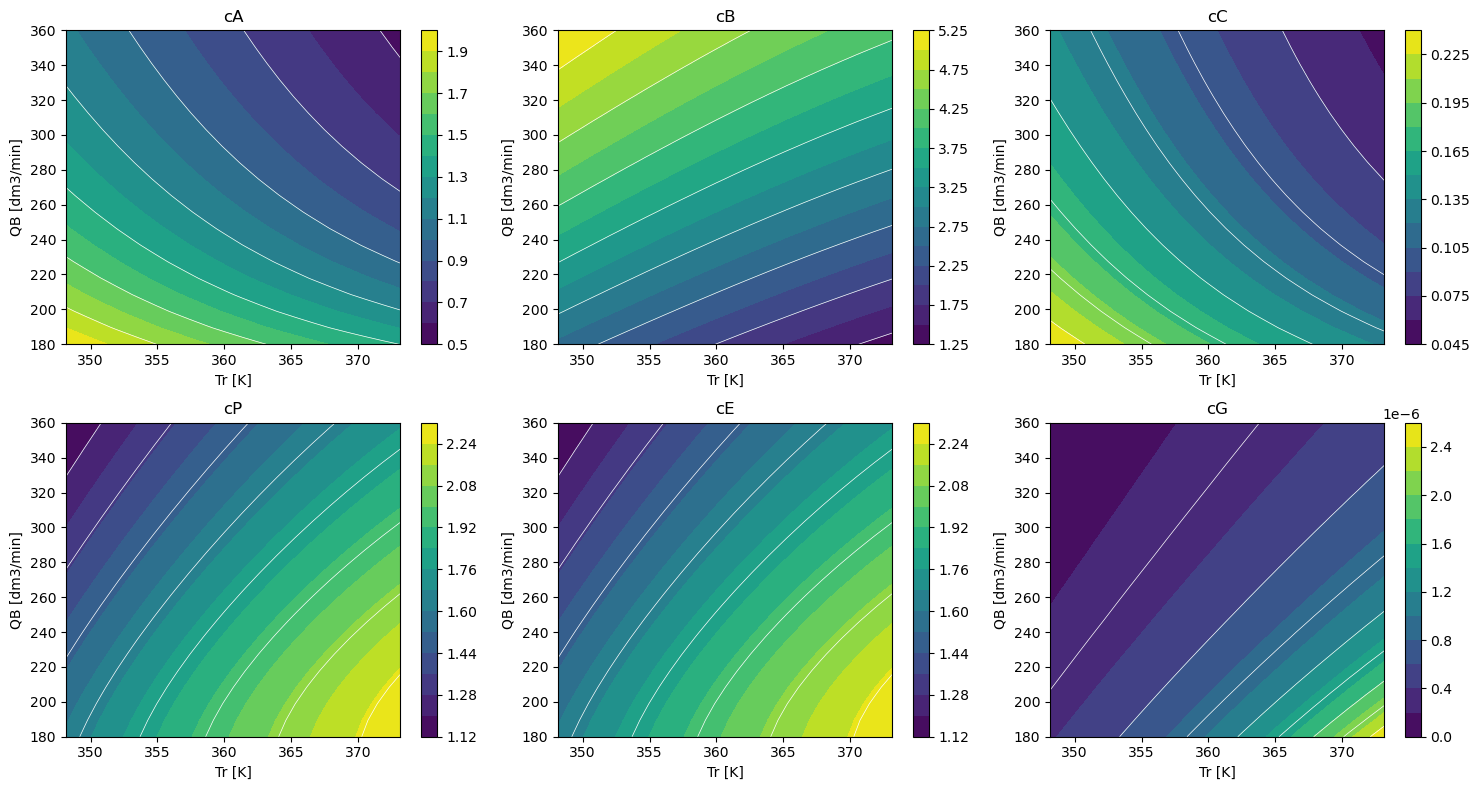

In [11]:
# Visualize
X_train = np.array(X_train)   # shape (400, 2) -> QB, Tr
y_train = np.array(y_train)   # shape (400, 6) -> cA, cB, cC, cP, cE, cG

labels = ["A", "B", "C", "P", "E", "G"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
Tr_grid, QB_grid = np.meshgrid(Tr_values, QB_values)

for i, ax in enumerate(axes.flatten()):
    c_grid = y_train[:, i].reshape(len(QB_values), len(Tr_values))
    cs = ax.contourf(Tr_grid, QB_grid, c_grid, levels=15, cmap="viridis")
    ax.contour(Tr_grid, QB_grid, c_grid, levels=8, colors="white", linewidths=0.5)
    ax.set_xlabel("Tr [K]")
    ax.set_ylabel("QB [dm3/min]")
    ax.set_title(f"c{labels[i]}")
    plt.colorbar(cs, ax=ax)

plt.tight_layout()
plt.show()

#### Generating Dynamic Training Data